This project implements Linear Regression, Ridge Regression, and Lasso Regression from scratch using NumPy and Gradient Descent.

import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

Dataset is loaded

In [3]:
data = fetch_california_housing()

X = data.data
y = data.target

print(X.shape)
print(y.shape)

(20640, 8)
(20640,)


In [4]:
print(data.feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


Training and testing data is splitted

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(16512, 8)
(4128, 8)


Normalising the data

In [6]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

print(X_train[:5])

[[-0.326196    0.34849025 -0.17491646 -0.20836543  0.76827628  0.05137609
  -1.3728112   1.27258656]
 [-0.03584338  1.61811813 -0.40283542 -0.12853018 -0.09890135 -0.11736222
  -0.87669601  0.70916212]
 [ 0.14470145 -1.95271028  0.08821601 -0.25753771 -0.44981806 -0.03227969
  -0.46014647 -0.44760309]
 [-1.01786438  0.58654547 -0.60001532 -0.14515634 -0.00743434  0.07750687
  -1.38217186  1.23269811]
 [-0.17148831  1.14200767  0.3490073   0.08662432 -0.48587717 -0.06883176
   0.5320839  -0.10855122]]


Weight and bias initialse

LINEAR REGRESSION

In [7]:
n_features = X_train.shape[1]

weights = np.zeros(n_features)
bias = 0

print(weights)
print(bias)

[0. 0. 0. 0. 0. 0. 0. 0.]
0


Prediction function

In [8]:
def predict(X, weights, bias):
    return np.dot(X, weights) + bias

Cost funtion

In [9]:
def compute_cost(y_true, y_pred):
    n = len(y_true)

    cost = (1/n) * np.sum((y_true - y_pred) ** 2)

    return cost

Training for gradient descent

In [10]:
learning_rate = 0.01
epochs = 1000

losses = []

n = len(X_train)

for epoch in range(epochs):

    y_pred = predict(X_train, weights, bias)

    dw = (-2/n) * np.dot(X_train.T, (y_train - y_pred))
    db = (-2/n) * np.sum(y_train - y_pred)

    weights = weights - learning_rate * dw
    bias = bias - learning_rate * db

    loss = compute_cost(y_train, y_pred)
    losses.append(loss)

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss}")

Epoch 0, Loss: 5.629742323103131
Epoch 100, Loss: 0.7103658676026788
Epoch 200, Loss: 0.5953130085792435
Epoch 300, Loss: 0.5732304657671403
Epoch 400, Loss: 0.5584093310450804
Epoch 500, Loss: 0.5476601015303805
Epoch 600, Loss: 0.5398283477804549
Epoch 700, Loss: 0.5341100200814504
Epoch 800, Loss: 0.5299255181901082
Epoch 900, Loss: 0.5268559059337552


Testing it

In [11]:
y_test_pred = predict(X_test, weights, bias)

test_loss = compute_cost(y_test, y_test_pred)

print("Test Loss:", test_loss)

Test Loss: 0.5545795065308549


Ploting a graph for loss

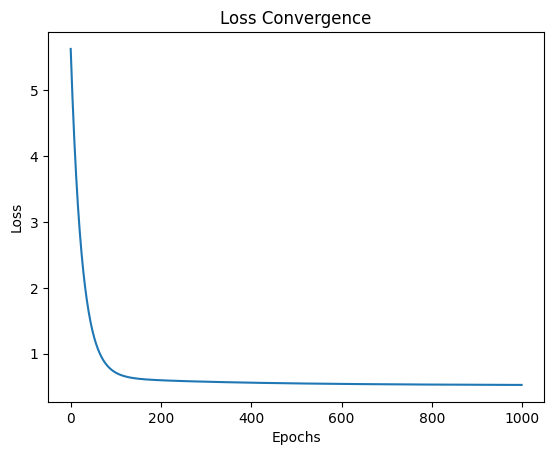

In [12]:
plt.plot(losses)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Convergence")

plt.show()

Reintialise the weights for L2 Regularisation

 RIDGE REGRESSION 

In [13]:
weights_ridge = np.zeros(n_features)
bias_ridge = 0

Training for gradient descent

In [14]:
learning_rate = 0.01
epochs = 1000

lambda_param = 0.1

ridge_losses = []

n = len(X_train)

for epoch in range(epochs):

    y_pred = predict(X_train, weights_ridge, bias_ridge)

    dw = (-2/n) * np.dot(X_train.T, (y_train - y_pred)) + 2 * lambda_param * weights_ridge

    db = (-2/n) * np.sum(y_train - y_pred)

    weights_ridge = weights_ridge - learning_rate * dw
    bias_ridge = bias_ridge - learning_rate * db

    loss = compute_cost(y_train, y_pred)

    ridge_losses.append(loss)

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss}")

Epoch 0, Loss: 5.629742323103131
Epoch 100, Loss: 0.7256065565098738
Epoch 200, Loss: 0.611939934779251
Epoch 300, Loss: 0.5954787170302935
Epoch 400, Loss: 0.5864636669817831
Epoch 500, Loss: 0.5806475250406243
Epoch 600, Loss: 0.576774149464703
Epoch 700, Loss: 0.5741542947990322
Epoch 800, Loss: 0.5723643552143856
Epoch 900, Loss: 0.5711327244129579


Testing it

In [15]:
y_test_pred_ridge = predict(X_test, weights_ridge, bias_ridge)

ridge_test_loss = compute_cost(y_test, y_test_pred_ridge)

print("Ridge Test Loss:", ridge_test_loss)

Ridge Test Loss: 0.5839531070796717


Ploting the graph for the loss

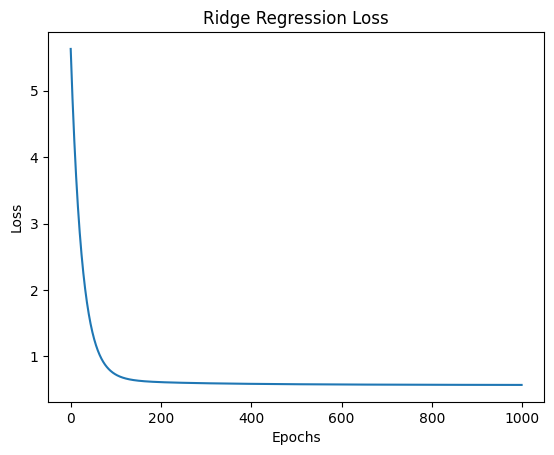

In [16]:
plt.plot(ridge_losses)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Ridge Regression Loss")

plt.show()

Reinitialising the weights for lassso regression L1 regularisation

LASSSO REGRESSION

In [17]:
weights_lasso = np.zeros(n_features)
bias_lasso = 0

Training for gradient descent

In [18]:
learning_rate = 0.01
epochs = 1000

lambda_param = 0.1

lasso_losses = []

n = len(X_train)

for epoch in range(epochs):

    y_pred = predict(X_train, weights_lasso, bias_lasso)

    dw = (-2/n) * np.dot(X_train.T, (y_train - y_pred)) + lambda_param * np.sign(weights_lasso)

    db = (-2/n) * np.sum(y_train - y_pred)

    weights_lasso = weights_lasso - learning_rate * dw
    bias_lasso = bias_lasso - learning_rate * db

    loss = compute_cost(y_train, y_pred)

    lasso_losses.append(loss)

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss}")

Epoch 0, Loss: 5.629742323103131
Epoch 100, Loss: 0.7431057845735856
Epoch 200, Loss: 0.636973402972466
Epoch 300, Loss: 0.6294040938646911
Epoch 400, Loss: 0.6258154432345459
Epoch 500, Loss: 0.623102592742548
Epoch 600, Loss: 0.6208081871246801
Epoch 700, Loss: 0.6187673465147456
Epoch 800, Loss: 0.6169786523646067
Epoch 900, Loss: 0.6155279892979042


Testing

In [19]:
y_test_pred_lasso = predict(X_test, weights_lasso, bias_lasso)

lasso_test_loss = compute_cost(y_test, y_test_pred_lasso)

print("Lasso Test Loss:", lasso_test_loss)

Lasso Test Loss: 0.6242082923982145


Ploting the graph for the loss

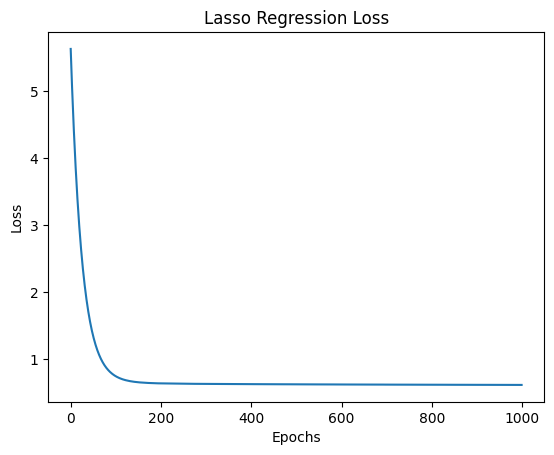

In [20]:
plt.plot(lasso_losses)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Lasso Regression Loss")

plt.show()

Comparison of  results

In [21]:
print("Linear Regression Test Loss:", test_loss)

print("Ridge Regression Test Loss:", ridge_test_loss)

print("Lasso Regression Test Loss:", lasso_test_loss)

Linear Regression Test Loss: 0.5545795065308549
Ridge Regression Test Loss: 0.5839531070796717
Lasso Regression Test Loss: 0.6242082923982145
